In [1]:
import numpy as np
import json, copy, os, glob
import scipy.integrate as spi
import astropy.units as u
from astropy.coordinates import SkyCoord
import astropy.cosmology.units as cu
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from mpl_toolkits.axes_grid1 import AxesGrid
from datetime import date

from enterprise_extensions import model_utils
#sns.color_palette("YlOrBr", as_cmap=True)

from astropy import units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib import patheffects
from matplotlib import text

import glob
import json
import h5py
import healpy as hp
import scipy.constants as sc
import emcee

from numba.typed import List

import sys
import h5py
import healpy as hp
from healpy.newvisufunc import projview, newprojplot

#from la_forge import core as co
#from la_forge.utils import bayes_fac
#import seaborn as sns
'''
import la_forge.core as co
import la_forge.diagnostics as dg

from la_forge.rednoise import gorilla_bf
from pint.models import get_model
'''

'\nimport la_forge.core as co\nimport la_forge.diagnostics as dg\n\nfrom la_forge.rednoise import gorilla_bf\nfrom pint.models import get_model\n'

In [2]:
#conda install conda-forge::la_forge

In [2]:
def compute_levels(H, X, Y, levels=(0.68, 0.95)):
    # Compute the density levels.
    Hflat = H.flatten()
    inds = np.argsort(Hflat)[::-1]
    Hflat = Hflat[inds]
    sm = np.cumsum(Hflat)
    sm /= sm[-1]
    V = np.empty(len(levels))
    for i, v0 in enumerate(levels):
        try:
            V[i] = Hflat[sm <= v0][-1]
        except IndexError:
            V[i] = Hflat[0]
    V.sort()
    m = np.diff(V) == 0
    if np.any(m) and not quiet:
        logging.warning("Too few points to create valid contours")
    while np.any(m):
        V[np.where(m)[0][0]] *= 1.0 - 1e-4
        m = np.diff(V) == 0
    V.sort()

    # Compute the bin centers.
    X1, Y1 = 0.5 * (X[1:] + X[:-1]), 0.5 * (Y[1:] + Y[:-1])

    # Extend the array for the sake of the contours at the plot edges.
    H2 = H.min() + np.zeros((H.shape[0] + 4, H.shape[1] + 4))
    H2[2:-2, 2:-2] = H
    H2[2:-2, 1] = H[:, 0]
    H2[2:-2, -2] = H[:, -1]
    H2[1, 2:-2] = H[0]
    H2[-2, 2:-2] = H[-1]
    H2[1, 1] = H[0, 0]
    H2[1, -2] = H[0, -1]
    H2[-2, 1] = H[-1, 0]
    H2[-2, -2] = H[-1, -1]
    X2 = np.concatenate(
        [
            X1[0] + np.array([-2, -1]) * np.diff(X1[:2]),
            X1,
            X1[-1] + np.array([1, 2]) * np.diff(X1[-2:]),
        ]
    )
    Y2 = np.concatenate(
        [
            Y1[0] + np.array([-2, -1]) * np.diff(Y1[:2]),
            Y1,
            Y1[-1] + np.array([1, 2]) * np.diff(Y1[-2:]),
        ]
    )
    return H2, X2, Y2, V

In [3]:
def get_bayes_fac(c, amp_param='log10_mc'):

    BF,BF_err = model_utils.bayes_fac(samples = samples_cold[0][::,4], logAmax=-11)
    print('log10A BF = ', BF, " +- ", BF_err)

    return BF
    '''
    idx = c.params.index(amp_param)
    pmin = float(c.priors[idx][c.priors[idx].index('pmin')+5:
                               c.priors[idx].index(', pmax')])
    pmax = float(c.priors[idx][c.priors[idx].index('pmax')+5:
                               c.priors[idx].index(')')])
    BF, _ = bayes_fac(c.chain[c.burn:, idx], logAmin=pmin, logAmax=pmax)
    if np.isnan(BF):
        BF = gorilla_bf(c.chain[c.burn:, idx], max=pmax, min=pmin, nbins=20)
    return BF
    '''

In [4]:
def skymap_ra(ra):
    return -ra + np.pi

In [5]:
def plot_BF_skymap(c, ra_deg ,dec_deg, BFcond=True, BFs=None, c_NGC3115=None, pcolor=True, bins=40,
                   BF_cmap='bone_r', contour=False, levels=(0.1,0.25,0.5,0.95), cmap='copper',
                   label_psrs=[], save=None, psrsize=55, xaxis_color='k',
                   logBF=False, include_BFcbar=True, BF_vmin=0, BF_vmax='auto', psr_color='blue'):
    """
    Plots a skymap w/ CW significance in terms of Bayes factors. Can plot the CW BF from
    one or more targeted searches, as well as either the posterior from an all-sky search,
    or the posterior converted into an expected Bayes factor from a targeted search, derived from the
    all sky search results. Also plots pulsar locations.

    Parameters
    ----------
    c : la_forge.core.Core
        The core containing the posteriors from an all-sky CW search.
    psr_RA : dictionary
        RA values of the pulsars to be plotted, in degrees. Keys are pulsar names.
    psr_DEC : dictionary
        DEC values of the pulsars to be plotted, in degrees. Keys are pulsar names.
    BFcond : bool, optional
        If True, the posterior probability over sky coordinates will be converted to a Bayes factor
        map. Default is True. Does nothing if pcolor = False.
    BFs : dictionary, optional
        Bayes Factor values corresponding to targeted (fixed-sky) searches. Keys are a string
        indicating the RA and DEC (separated by an underscore) indicating where to flot the targeted
        search. Default is None.
    c_NGC3115 : la_forge.core.Core, optional
        An additional la_forge core object containing the NGC 3115 targeted search result.
        Default is None.
    pcolor : bool, optional
        If True, plots all-sky search results as a 2D histogram (using the pcolormesh method).
        Default is True.
    bins : int, optional
        Number of bins to use for the 2D histogram. Default is 40.
    BF_cmap : str, optional
        Colormap to use for the all-sky Bayes Factor map. Default is 'bone_r'.
    contour : bool, optional
        If True, adds contour lines to the skymap based on the all-sky search posteriors. Default is False.
    levels : tuple, optional
        Posterior probability levels to enclose if contour = True. Default is (0.1, 0.25, 0.5, 0.68).
    cmap : str, optional
        Colormap to use for the contour method. Default is 'copper'.
    label_psrs : list, optional
        List of pulsars to be explicitly labeled on the skymap. Default is an empty list.
    save : str, optional
        Directory where to save the skymap to, if specified. Default is None.
    psrsize : int, optional
        Size of the markers representing pulsars on the skymap. Default is 55.
    xaxis_color : str, optional
        Color of the x-axis on the skymap. Default is 'k' (black).
    logBF : bool, optional
        If True, uses a logarithmic scale toi represented the targeted (fixed-sky loc) Bayes Factor
        values. Default is False.
    include_BFcbar : bool, optional
        If True, includes a colorbar for the Bayes Factor map. Default is True.
    BF_vmin : float, optional
        Minimum value for the Bayes Factor color scaling. Default is 0.
    BF_vmax : float or str, optional
        Maximum value for the Bayes Factor color scaling. If set to 'auto', the maximum value 
        is determined automatically. Default is 'auto'.
    psr_color : str, optional
        Color of the pulsar markers on the skymap. Default is 'blue'.
    """
    
    freq = -6.8    #CHANGE TO FIXED FREQUENCY VALUE
    
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(111, projection='mollweide')
    
    # plot Bayes factor distribution from core
    BF_variedCW = get_bayes_fac(c)
    phi_post = skymap_ra(samples_cold[0][::,2])#skymap_ra(c('gwphi'))
    gwtheta_post = -np.arccos(samples_cold[0][::,0]) + np.pi/2 #-np.arccos(c('cos_gwtheta')) + np.pi/2

    print("min phi_post", np.min(phi_post))
    print("max phi_post",np.max(phi_post))
    #print(c('cos_gwtheta'))
    print("bjorns gwtheta_post",gwtheta_post)
    #print("min cos_gwtheta",np.min(c('cos_gwtheta')))
    #print("max cos_gwtheta",np.max(c('cos_gwtheta')))
    print("min gwtheta_post",np.min(gwtheta_post))
    print("max gwtheta_post",np.max(gwtheta_post))
    
    #print(phi_post)
    #print(np.min(phi_post))
    #print(np.max(phi_post))
    #print("\n",gwtheta_post)
    #print(np.min(gwtheta_post))
    #print(np.max(gwtheta_post))
    
    # use cos(gwtheta) for Bayes factor
    post_hist, phi, theta = np.histogram2d(phi_post, gwtheta_post, bins=bins, density=True)
    #skyloc_prior = np.cos(theta)/(4*np.pi)
    
    cos_theta_grid = ((np.cos(theta)[:-1]+np.cos(theta)[1:])/2)[np.newaxis,:]
    skyloc_prior = cos_theta_grid/(4*np.pi)
    # need to divide 
    BF = BF_variedCW/skyloc_prior*post_hist
    #BF2 = post_hist
    if BF_vmax == 'auto':
        BF_vmax = np.max(BF)
    if pcolor:
        #ax.imshow(hist.T, cmap='bone_r', extent=[-np.pi,np.pi,-np.pi,np.pi], origin='lower')
        # sns.color_palette("YlOrBr", as_cmap=True)
        if BFcond:
            #pcm = ax.pcolormesh(phi, theta, BF.T, cmap='bone_r', zorder=0)
            pcm = ax.pcolormesh(np.linspace(-np.pi, np.pi, bins),
                                np.linspace(-np.pi/2, np.pi/2, bins),
                                BF.T, cmap=BF_cmap, zorder=0, shading='gouraud',
                                vmin=BF_vmin, vmax=BF_vmax)
            if include_BFcbar:
                if BFs is None:
                    cb = plt.colorbar(pcm, ax=ax, location="right", fraction=0.036, pad=0.07)
                else:
                    cb = plt.colorbar(pcm, ax=ax, location="right", fraction=0.036, pad=-0.1)
                cb.set_label('Bayes Factor for fixed frequency \n (from all-sky search)', fontsize=13)
        else:
            #pcm = ax.pcolormesh(phi, theta, post_hist.T, cmap='bone_r', zorder=0)
            pcm = ax.pcolormesh(np.linspace(-np.pi, np.pi, bins),
                                np.linspace(-np.pi/2, np.pi/2, bins),
                                post_hist.T, cmap='bone_r', zorder=0, shading='gouraud')
            if include_BFcbar:
                if BFs is None:
                    cb = plt.colorbar(pcm, ax=ax, location="right", fraction=0.036, pad=0.07)
                else:
                    cb = plt.colorbar(pcm, ax=ax, location="right", fraction=0.036, pad=-0.1)
                cb.set_label('Posterior Probability', fontsize=13)
    if contour:
        # use gwtheta for probability
        H2, X2, Y2, V = compute_levels(post_hist, phi, theta, levels=levels)
        CS = plt.contour(X2, Y2, H2.T, V, cmap=cmap, vmin=0, vmax=np.max(V))
    
    # plot fixed point bayes factors
    if BFs is not None:
        if logBF:
            #vmin = np.log10(np.min(list(BFs.values())))
            vmax = np.log10(np.max(list(BFs.values())))
            vmin = -vmax
            cmap = 'RdGy_r'
            #cmap = shiftedColorMap(matplotlib.cm.RdGy_r, start=vmin, midpoint=0, stop=vmax)
        else:
            vmin = 0
            vmax = np.max(list(BFs.values()))
            cmap = 'inferno'
        for ra_dec in BFs:
            if logBF:
                val = np.log10(BFs[ra_dec])
            else:
                val = BFs[ra_dec]
            ra, dec = ra_dec.split('_')
            coord = SkyCoord(ra, dec, frame='icrs')
            
            
            #hp.mollview(BFs,title="Sky distribution of 3C66B and 15yr pulsars (Stars wrt amplitude/ToA RMS)", cbar = None, cmap = 'viridis', min = 0, max = 1, rot = 180)
            hp.graticule(15,30)

            #hp.visufunc.projscatter([skymap_ra(np.radians(coord.ra.value))], [np.radians(coord.dec.value)],c=val, cmap=cmap, vmin=vmin, vmax=vmax,marker='o', s=160, edgecolors='k', lw=0.5, zorder=2)
            sc = ax.scatter([skymap_ra(np.radians(coord.ra.value))], [np.radians(coord.dec.value)],
                            c=val, cmap=cmap, vmin=vmin, vmax=vmax,
                          marker='o', s=160, edgecolors='k', lw=0.5, zorder=2)
            
        cb = plt.colorbar(sc, ax=ax, location="bottom", fraction=0.046, pad=0.07)
        if logBF:
            cb.set_label('Log Bayes Factor for fixed frequency', fontsize=15)
        else:
            cb.set_label('Bayes Factor for fixed sky location \n (from fixed searches)', fontsize=15)
    if c_NGC3115 is not None:
        if logBF:
            val_NGC3115 = np.log10(get_bayes_fac(c_NGC3115))
        else:
            val_NGC3115 = get_bayes_fac(c_NGC3115)
        coord = SkyCoord('10h05m13.927s', '-07d43m06.983s', frame='icrs')
        
        ax.scatter([skymap_ra(np.radians(coord.ra.value))], [np.radians(coord.dec.value)],
                   c=val_NGC3115, cmap=cmap, vmin=vmin, vmax=vmax,
                   marker='o', s=160, edgecolors='k', lw=0.5, zorder=2)
        
    
    # Convert pulsar RA and DEC to radians
    ra_rad = np.radians(np.array(list(ra_deg)))
    dec_rad = np.radians(np.array(list(dec_deg)))
    #for i in range(len(ra_rad)):
     #   ra_rad[i] = skymap_ra(ra_rad[i])
    
    # Plot pulsar sky locations
    
    #hp.visufunc.projscatter(dec_rad,ra_rad,marker='*',color='white',edgecolors='k',s=psrsize, label = '15yr Pulsars')

    ax.scatter( np.pi-ra_rad, dec_rad,color=psr_color, marker='*', s=psrsize, label='Pulsars', zorder=3,
              edgecolor='c', lw=0.3)
    
#################REMOVE LATER
    coord = SkyCoord('10h05m13.927s', '-07d43m06.983s', frame='icrs')
    #ax.scatter([skymap_ra(np.radians(coord.ra.value))], [np.radians(coord.dec.value)],
     #      marker='o', s=160, edgecolors='k', lw=0.5, zorder=2) #c=val_NGC3115, cmap=cmap, vmin=vmin, vmax=vmax,
    print("values", [skymap_ra(np.radians(coord.ra.value))],  [np.radians(coord.dec.value)])
    ax.scatter([skymap_ra(np.radians(coord.ra.value))], [np.radians(coord.dec.value)],color='black',
           marker='D', s=200, edgecolors='k', lw=0.5, zorder=2,label='NGC 3115')
        ####################################
    
   # for i, pname in enumerate(label_psrs):
    #    ra_rad_p = np.radians(psr_RA[pname])
     #   if ra_rad_p > np.pi:
      #      ra_rad_p -= 2*np.pi
       #     ra_rad_p *= -1
        #    ra_rad_p -= np.pi
        #else:
         #   ra_rad_p *= -1
          #  ra_rad_p += np.pi
        #ax.scatter(ra_rad_p, np.radians(psr_DEC[pname]),
         #          color=f'C{i+1}', marker='*', s=psrsize, label=pname, zorder=3)
    
    '''for pname in label_psrs:
        ra_rad_p = np.radians(psr_RA[pname])
        if ra_rad_p > np.pi:
            ra_rad_p -= 2*np.pi
            ra_rad_p *= -1
            ra_rad_p -= np.pi
        else:
            ra_rad_p *= -1
            ra_rad_p += np.pi
        ax.text(ra_rad_p, np.radians(psr_DEC[pname]), pname)'''
    
    # Plot NGC 3115 position
    #c_ngc3115 = SkyCoord('10h05m13.927s', '-07d43m06.983s', frame='icrs')
    #ax.scatter([skymap_ra(np.radians(c_ngc3115.ra.value))], [np.radians(c_ngc3115.dec.value)],
     #          color='w', marker='s', s=35, label='NGC 3115', zorder=4, edgecolor='k')
    
    # Set grid and labels
    ax.grid(True)
    ax.set_xlabel('RA')
    ax.set_ylabel('DEC')
    
    # Show legend
    ax.legend()
    
    xlabels = [r'$22^{\rm{h}}$', r'$20^{\rm{h}}$', r'$18^{\rm{h}}$',
               r'$16^{\rm{h}}$', r'$14^{\rm{h}}$', r'$12^{\rm{h}}$',
               r'$10^{\rm{h}}$', r'$8^{\rm{h}}$', r'$6^{\rm{h}}$',
               r'$4^{\rm{h}}$', r'$2^{\rm{h}}$']
    
    #ax.set_xticklabels(ax.get_xticklabels()[::-1])  # flip xticklabels
    ax.set_xticklabels(xlabels, color=xaxis_color)
    
    
    ax.set_title("log10_fGW = %1.1f" %freq + " (log10_h SD BF = %1.2f)" %BF_variedCW, fontsize = 15)
    fig.tight_layout()
    plt.savefig("/scratch/na00078/QuickCW_targeted_runs/results/all_sky_freq/plots/all_sky_%1.1f_withBF_NGC3115_without_J1713.png"%freq)
    if save:
        savestr = 'skymap'
        if BFs is not None:
            if logBF:
                savestr += '_logBFs'
            else:
                savestr += '_BFs'
        if BFcond:
            savestr = 'BF' + savestr
        print(savestr)
        plt.savefig(f'{save}/{savestr}.png', format='png', dpi=300, bbox_inches='tight')

In [6]:
#Get pulsar positions

psrnames = []
psr_thetas = []
psr_phis = []

f = open('/scratch/na00078/15yr_data/NG15yr_pulsar_position.json')
data = json.load(f)
#print(data)

for i in data:
    
    psrname = i
    psrnames.append(psrname)
    #pos = [np.cos(DEC1)* np.cos(RA1), np.cos(DEC1)* np.sin(RA1), np.sin(DEC1)]
    pos = data[i][0]
    #print(data[i][1])
    psr_theta = data[i][1][0]
    psr_phi = data[i][1][1]
    psr_thetas.append(psr_theta)
    psr_phis.append(psr_phi)
    
print("DEC",psr_thetas)
print("\n","RA",psr_phis)
print(np.max(psr_phis))
print(np.min(psr_phis))

dec_deg = []
for j in psr_thetas:
    rad1 = 90-(j*(180/np.pi))
    dec_deg.append(rad1)
    
#print("\n",dec_deg)

ra_deg = []
for k in psr_phis:
    rad2 = k*(180/np.pi)
    ra_deg.append(rad2)
    
#print("\n",ra_deg)
 
dec_rad = []
for l in dec_deg:
    rad3 = l*(np.pi/180)
    dec_rad.append(rad3)
    
#print("\n",dec_rad)

DEC [1.402309470247295, 1.1961263783076368, 1.0644403654535461, 1.4069106122091741, 1.4859553047915817, 0.8462650016545497, 1.0356472271711716, 2.3955117826044, 1.4147587858403063, 1.2944228618491012, 0.9082694740047054, 1.9374499528382565, 1.6059318281165829, 2.1554529590061486, 0.6722426580015057, 0.6637344702612409, 1.4838617893652168, 0.41289868950231523, 1.9032573655081908, 0.6437247348118929, 2.3142745649338314, 1.3957148538559778, 1.6985916851125409, 0.20367644310412114, 1.5559609124726697, 1.2385434637161137, 2.1557066531647466, 2.1100518863983795, 1.9636475113224514, 0.9149309105272325, 1.1798000905283206, 1.7875017530432538, 1.9034824426761514, 1.4347700281756965, 1.826201201565954, 1.97353700413495, 1.5087844920123181, 1.3288546032923558, 1.7729382474138236, 1.3910641940096846, 2.2796658269094836, 2.07629507616823, 1.9443148553752547, 1.9912193121055584, 1.7211617721586951, 1.7667150526251698, 1.342817497369191, 1.5104897151459828, 2.2294383326886744, 1.3449438935944202, 1.3

In [ ]:
#CHANGE THIS FILE BASED ON YOUR RUN OUTPUT

core = "/scratch/na00078/QuickCW_targeted_runs/results/all_sky_freq/all_sky_fGW_7_3_wo_J1713_outfile.h5"     #co.Core(corepath='/scratch/na00078/QuickCW_targeted_runs/results/NGC3115_allsky_core.h5')

with h5py.File(core, 'r') as f:
    Ts = f['T-ladder'][...]
    samples_cold = f['samples_cold'][:,:,:]
    print(samples_cold[-1].shape)
    log_likelihood = f['log_likelihood'][:1,:]
    print(log_likelihood.shape)
    par_names = [x.decode('UTF-8') for x in list(f['par_names'])]
    acc_fraction = f['acc_fraction'][...]
    fisher_diag = f['fisher_diag'][...]

In [37]:
#THESE FILES SHOULD NOT BE CHANGED
ra = np.genfromtxt('/scratch/na00078/QuickCW_targeted_runs/post_processing_scripts/NGC3115/txt_files/gwphi.txt')
print(np.min(ra))
print(np.max(ra))
dec =np.genfromtxt('/scratch/na00078/QuickCW_targeted_runs/post_processing_scripts/NGC3115/txt_files/cos_gwtheta.txt')
print(np.min(dec))
print(np.max(dec))

0.00010049682293618283
6.282922552406807
-0.9999592611944104
0.9999375785177382


log10A BF =  13.54409522726139  +-  0.042865865222777966
min phi_post -3.140981
max phi_post 3.1412315
bjorns gwtheta_post [-0.19987464 -0.19987464 -0.19987464 ...  0.2980703   0.2980703
  0.2980703 ]
min gwtheta_post -1.565081
max gwtheta_post 1.5404117
values [0.5007693599278484] [-0.13471509515158098]


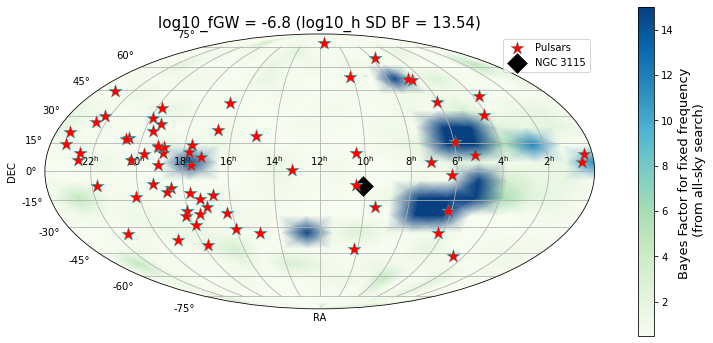

In [39]:
#Plot skymap

levels = (0.25, 0.68, 0.95)
plot_BF_skymap(samples_cold,ra_deg, dec_deg ,BFcond=True, BFs=None, c_NGC3115=None,
               bins = 20,xaxis_color='black', psr_color='red', pcolor=True, contour=False, 
               psrsize=200, label_psrs=['J1713+0747'], levels=levels, cmap='viridis',
               save=False, BF_vmin=1.5-1, BF_vmax=15, BF_cmap='GnBu')#'YlGnBu')
